# MDR-TS v2.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v2.1  
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

For other info see `MDR-TS-v1.0`

## 0. Imports

In [80]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# SHAP
import shap

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)

imports loaded
using: cpu


## 1. Environment Setup

In [38]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [39]:
# Project paths
VERSION = "v2"
SUBVERSION = "v2.1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits/base_1.0/"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base/
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [40]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base/train_base.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base/val_base.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/base/test_base.csv
train: dropped columns ['slope', 'elev']

train: shape=(9709, 17)
train: columns=17
val: dropped columns ['slope', 'elev']

val: shape=(2080, 17)
val: columns=17
test: dropped columns ['slope', 'elev']

test: shape=(2080, 17)
test: columns=17


In [41]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 17

columns:
['station_id', 'date', 'longitude', 'latitude', 'rain_mm', 'precip_mm', 'air_temp_mean', 'rh_mean', 'solar_radiation', 'NDVI', 'NDMI', 'MSI', 's1_vv', 's1_vh', 'SAR_ratio', 'DOY', 'soil_moisture_5cm']


## 4. Data Sanity Checks

In [42]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    "rain_mm",
    "precip_mm",
    "air_temp_mean",
    "rh_mean",
    "solar_radiation",
    "NDVI",
    "NDMI",
    "MSI",
    "s1_vv",
    "s1_vh",
    "SAR_ratio",
    # "elev",
    # "slope",
    "DOY",
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 12
  Target:   soil_moisture_5cm


In [43]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [44]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-19 00:00:00
    val   min date: 2021-08-20 00:00:00
  Station Quinault:
    train max date: 2021-08-19 00:00:00
    val   min date: 2021-08-20 00:00:00
  Station Spokane:
    train max date: 2021-11-17 00:00:00
    val   min date: 2021-11-18 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [45]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     9709
  stations: ['Darrington', 'Quinault', 'Spokane']
  date range: 2011-10-06 00:00:00 -- 2021-11-17 00:00:00

VAL
  rows:     2080
  stations: ['Darrington', 'Quinault', 'Spokane']
  date range: 2021-08-20 00:00:00 -- 2024-02-28 00:00:00

TEST
  rows:     2080
  stations: ['Darrington', 'Quinault', 'Spokane']
  date range: 2023-09-03 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'Spokane']
val   ∩ test: ['Darrington', 'Quinault', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [46]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (9709, 12)
  X_val:   (2080, 12)
  X_test:  (2080, 12)
  y_train: (9709,)


### 6.2 Feature Overview

In [47]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
DOY,187.882789,100.120226,1.000000,366.000000
rh_mean,78.458554,16.486472,21.400000,100.000000
precip_mm,5.687424,11.766252,0.000000,127.600000
rain_mm,4.374230,10.443499,0.000000,127.600000
solar_radiation,12.048815,8.999870,0.000000,41.610000
air_temp_mean,10.313019,6.365472,-12.400000,30.300000
SAR_ratio,4.442692,0.723902,2.420880,7.880614
MSI,0.755232,0.216240,0.135812,1.294773
NDVI,0.402424,0.154587,-0.003464,0.887444
NDMI,0.155824,0.134118,-0.128454,0.760855


### 6.3 Feature Correlation

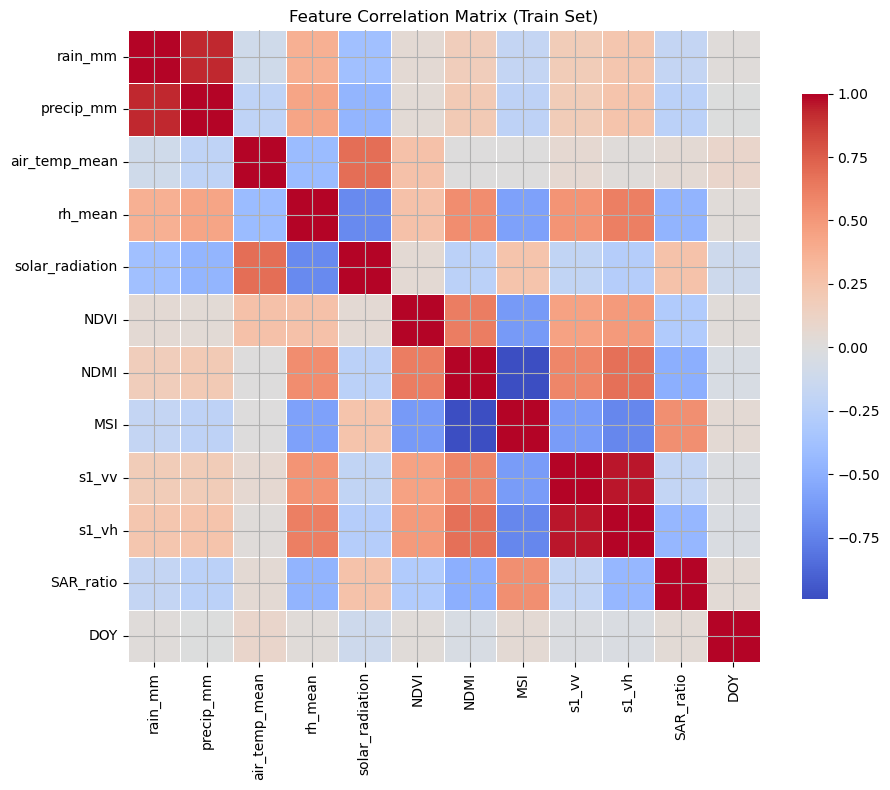

In [48]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [49]:
MODEL_CONFIG = {
    "n_estimators": 500,          # upper bound, early stopping will cap it
    "max_depth": 5, # can try 6 with stronger regularization
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

print("MODEL_CONFIG:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

MODEL_CONFIG:
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [50]:
model = XGBRegressor(**MODEL_CONFIG)
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


### 6.5 Feature Importance

In [51]:
# scaffolded for now

## 7. Training Loop

### 7.1 Fit Model

In [52]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print("Training complete")

[0]	validation_0-rmse:0.09733	validation_1-rmse:0.10313
[50]	validation_0-rmse:0.04192	validation_1-rmse:0.05761
[100]	validation_0-rmse:0.03630	validation_1-rmse:0.05698
[150]	validation_0-rmse:0.03348	validation_1-rmse:0.05740
[200]	validation_0-rmse:0.03139	validation_1-rmse:0.05800
[250]	validation_0-rmse:0.02974	validation_1-rmse:0.05841
[300]	validation_0-rmse:0.02846	validation_1-rmse:0.05876
[350]	validation_0-rmse:0.02726	validation_1-rmse:0.05927
[400]	validation_0-rmse:0.02624	validation_1-rmse:0.05944
[450]	validation_0-rmse:0.02536	validation_1-rmse:0.05963
[499]	validation_0-rmse:0.02459	validation_1-rmse:0.05973
Training complete


### 7.2 Predictions

In [53]:
yhat_train = model.predict(X_train)
yhat_val   = model.predict(X_val)
yhat_test  = model.predict(X_test)

print("Predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

Predictions generated
  yhat_train: (9709,)
  yhat_val:   (2080,)
  yhat_test:  (2080,)


### 7.3 Metrics

In [54]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

results = pd.DataFrame([
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
])

results

,split,MAE,RMSE,R2
0,train,0.017753,0.024585,0.940813
1,val,0.044369,0.059731,0.680582
2,test,0.043462,0.057166,0.653988


### 7.4 Diagnostics

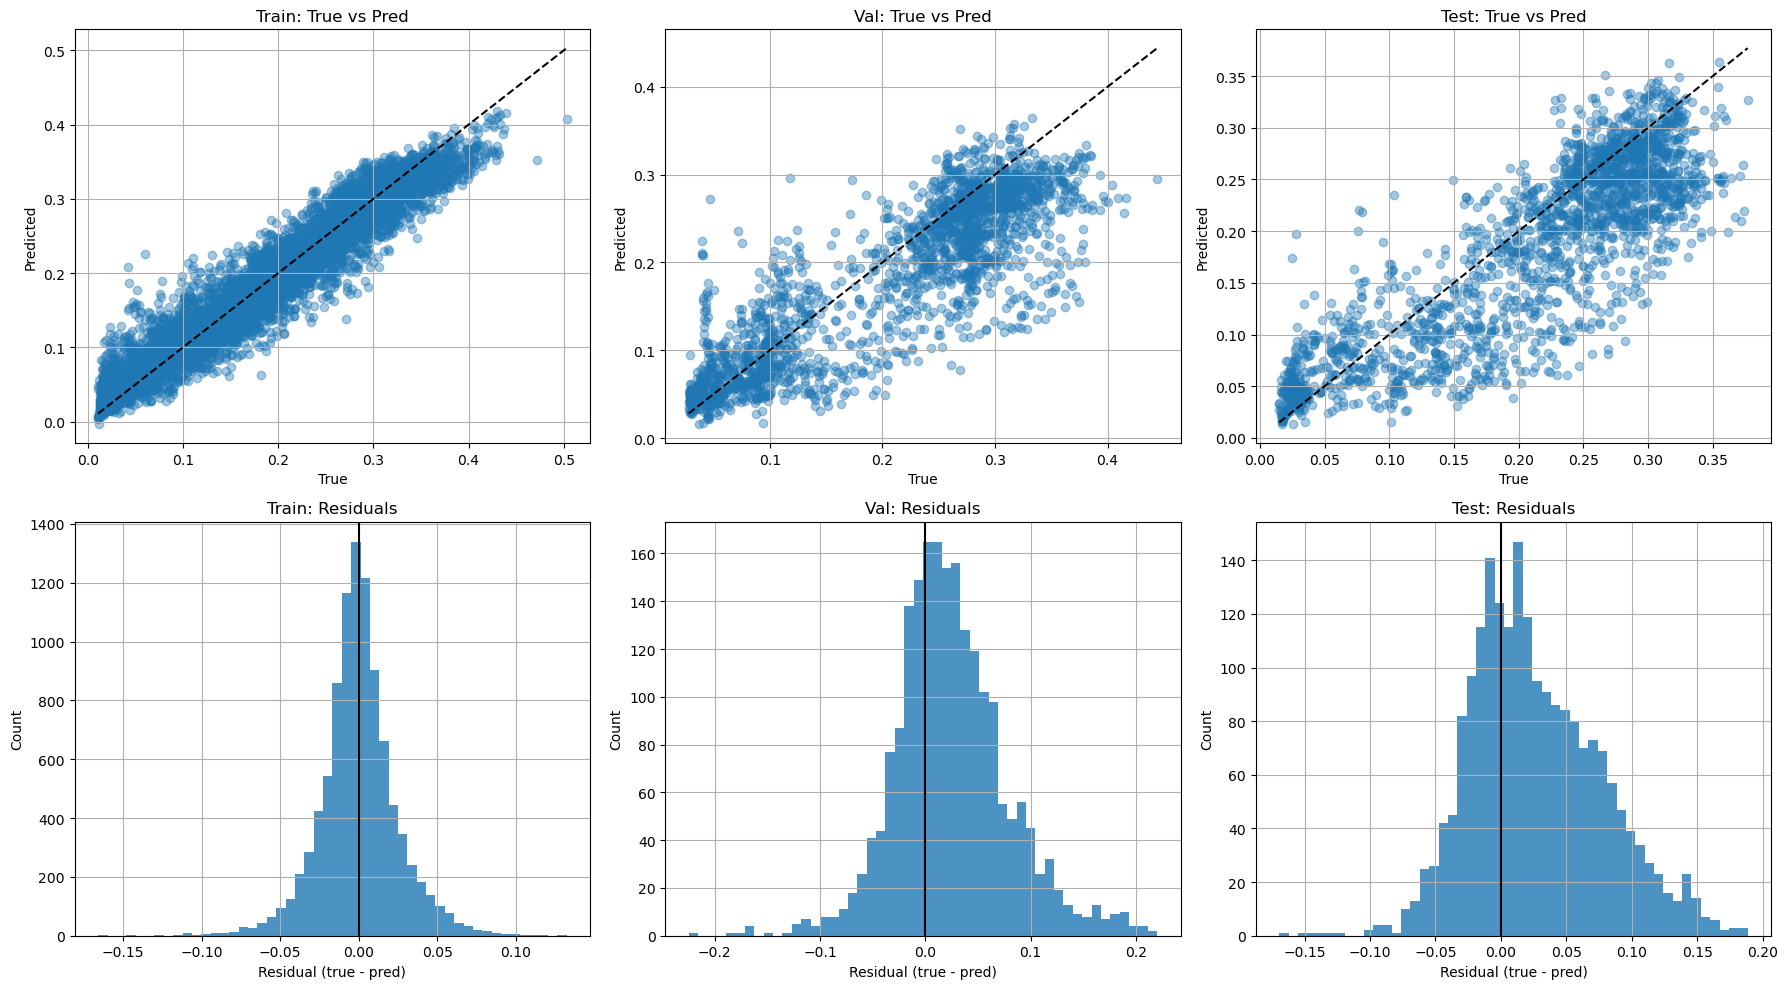

In [55]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

### 7.5 Feature Importance

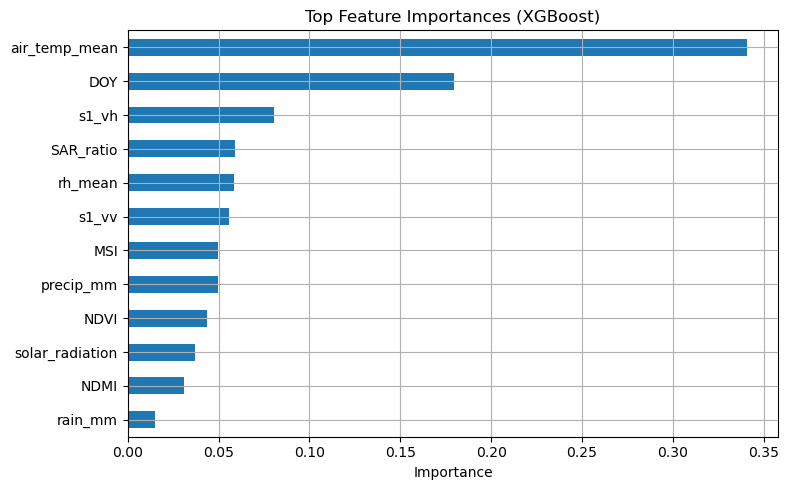

air_temp_mean      0.340861
DOY                0.179513
s1_vh              0.080392
SAR_ratio          0.059207
rh_mean            0.058287
s1_vv              0.055833
MSI                0.049653
precip_mm          0.049407
NDVI               0.043483
solar_radiation    0.036917
NDMI               0.031224
rain_mm            0.015223
dtype: float32

In [56]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Validation

### 8.1 Best Iteration & Early Stopping Behavior

In [57]:
if hasattr(model, "best_iteration"):
    print("Best boosting iteration:", model.best_iteration)
    print("Best validation score:", model.best_score)
else:
    print("Model was trained without early stopping.")

Model was trained without early stopping.


### 8.2 Validation Error by Time

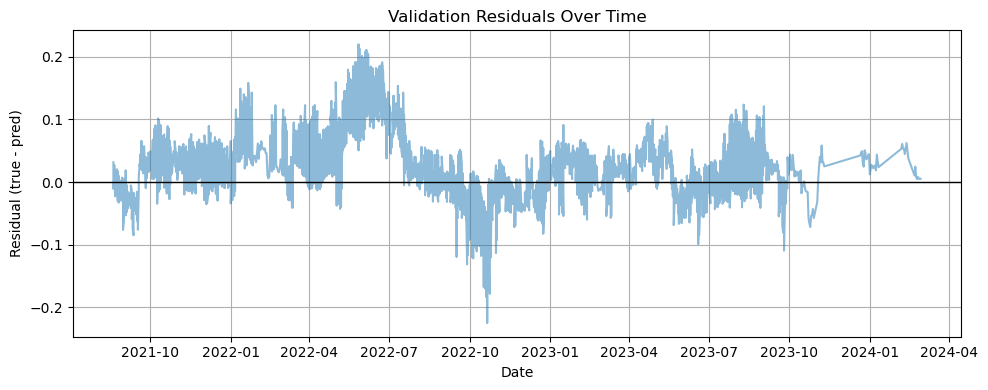

In [58]:
val_analysis = val_df.copy()
val_analysis["y_true"] = y_val.values
val_analysis["y_pred"] = yhat_val
val_analysis["residual"] = val_analysis["y_true"] - val_analysis["y_pred"]

# sort by time
val_analysis = val_analysis.sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(val_analysis["date"], val_analysis["residual"], alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.title("Validation Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (true - pred)")
plt.tight_layout()
plt.show()

### 8.3 Validation Residual Distribution

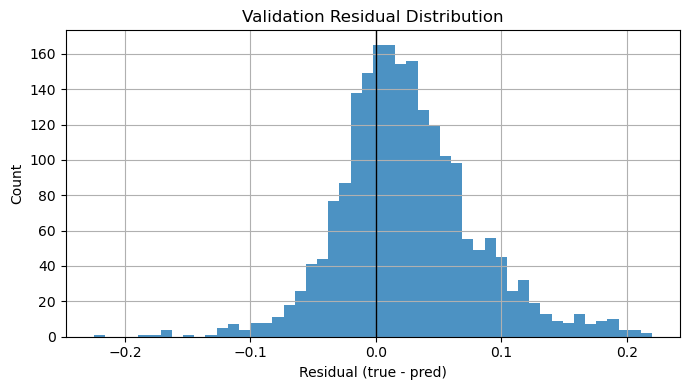

In [59]:
plt.figure(figsize=(7, 4))
plt.hist(val_analysis["residual"], bins=50, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.title("Validation Residual Distribution")
plt.tight_layout()
plt.show()

## 9. Evaluation

### 9.1 Test Metrics

In [60]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.043462,0.057166,0.653988,2080


### 9.2 Test Prediction Scatter

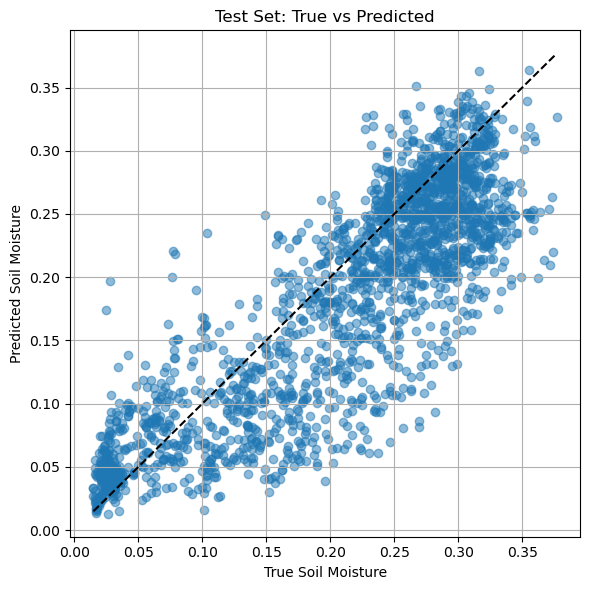

In [61]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 9.3 Test Residuals Over Time

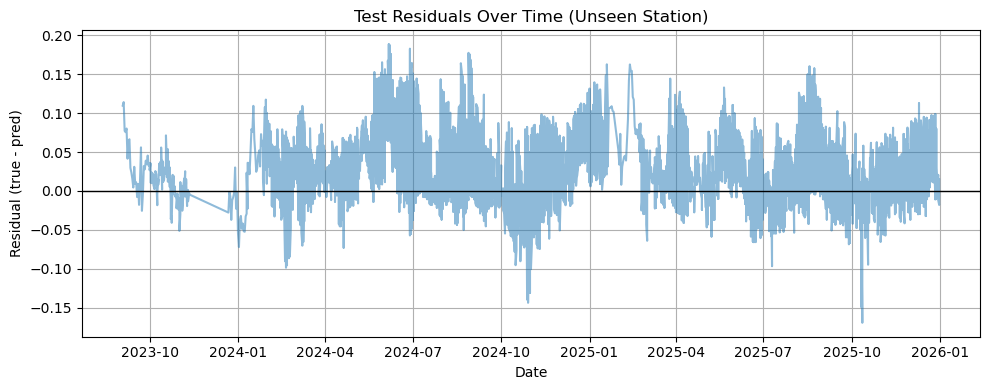

In [62]:
test_analysis = test_df.copy()
test_analysis["y_true"] = y_test.values
test_analysis["y_pred"] = yhat_test
test_analysis["residual"] = test_analysis["y_true"] - test_analysis["y_pred"]

test_analysis = test_analysis.sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(test_analysis["date"], test_analysis["residual"], alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Residual (true - pred)")
plt.title("Test Residuals Over Time (Unseen Station)")
plt.tight_layout()
plt.show()

### 9.4 Test Residual Distribution

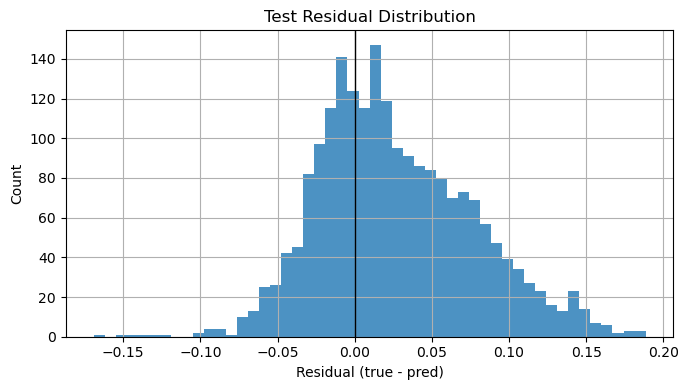

In [63]:
plt.figure(figsize=(7, 4))
plt.hist(test_analysis["residual"], bins=50, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.title("Test Residual Distribution")
plt.tight_layout()
plt.show()

### 9.5 Bias

In [64]:
print("VAL residual mean: ", float((y_val.values - yhat_val).mean()))
print("TEST residual mean:", float((y_test.values - yhat_test).mean()))
print("VAL pred range:    ", float(yhat_val.min()), "-->", float(yhat_val.max()))
print("TEST pred range:   ", float(yhat_test.min()), "-->", float(yhat_test.max()))

VAL residual mean:  0.02487489492596987
TEST residual mean: 0.026686365247077237
VAL pred range:     0.015487329103052616 --> 0.36445847153663635
TEST pred range:    0.013055216521024704 --> 0.36401206254959106


## 10. Metrics & Visalization

### 10.1 Consolidated Metrics
Summary of core regression metrics across all dataset splits

In [65]:
results = results.copy()  # from Section 7

results = results.set_index("split").loc[["train", "val", "test"]]
results

,MAE,RMSE,R2
split,,,
train,0.017753,0.024585,0.940813
val,0.044369,0.059731,0.680582
test,0.043462,0.057166,0.653988


### 10.2 Generalization Gap

In [66]:
gap = {
    "train -> val (MAE)": results.loc["val", "MAE"] - results.loc["train", "MAE"],
    "val -> test (MAE)":  results.loc["test", "MAE"] - results.loc["val", "MAE"],
}

pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.026617
val -> test (MAE),-0.000908


### 10.3 Feature Importance Recap

In [67]:
importances.head(10)

air_temp_mean      0.340861
DOY                0.179513
s1_vh              0.080392
SAR_ratio          0.059207
rh_mean            0.058287
s1_vv              0.055833
MSI                0.049653
precip_mm          0.049407
NDVI               0.043483
solar_radiation    0.036917
dtype: float32

## 11. Save Artifacts

In [68]:
from datetime import datetime

RUN_NAME = "mdr_ts_v2_1"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1/mdr_ts_v2_1_20260131_100442


In [69]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1/mdr_ts_v2_1_20260131_100442/model.json


In [70]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1/mdr_ts_v2_1_20260131_100442/run_metadata.json


In [71]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1/mdr_ts_v2_1_20260131_100442/metrics.csv


In [72]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR/Models/Temporal/v2/v2.1/mdr_ts_v2_1_20260131_100442/feature_importance.csv


In [73]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## 12. Notes & Experiments

Train models with one feature removed at a time to identify which features harm or help generalization

In [74]:
from copy import deepcopy

def train_and_eval(feature_cols, label, model_config):
    Xtr = train_df[feature_cols]
    Xva = val_df[feature_cols]
    Xte = test_df[feature_cols]

    ytr = train_df[TARGET_COL]
    yva = val_df[TARGET_COL]
    yte = test_df[TARGET_COL]

    m = XGBRegressor(**deepcopy(model_config))
    m.fit(Xtr, ytr, verbose=False)

    p_tr = m.predict(Xtr)
    p_va = m.predict(Xva)
    p_te = m.predict(Xte)

    out = {
        "label": label,
        "n_features": len(feature_cols),
        "features": feature_cols,

        "train_MAE": float(mean_absolute_error(ytr, p_tr)),
        "train_RMSE": float(np.sqrt(mean_squared_error(ytr, p_tr))),
        "train_R2": float(r2_score(ytr, p_tr)),

        "val_MAE": float(mean_absolute_error(yva, p_va)),
        "val_RMSE": float(np.sqrt(mean_squared_error(yva, p_va))),
        "val_R2": float(r2_score(yva, p_va)),
        "val_bias_mean_resid": float((yva.values - p_va).mean()),

        "test_MAE": float(mean_absolute_error(yte, p_te)),
        "test_RMSE": float(np.sqrt(mean_squared_error(yte, p_te))),
        "test_R2": float(r2_score(yte, p_te)),
        "test_bias_mean_resid": float((yte.values - p_te).mean()),
    }
    return out, m

# Run baseline + leave-one-out
ABLATION_RESULTS = []

# Baseline
base_res, _ = train_and_eval(FEATURE_COLS, "BASELINE", MODEL_CONFIG)
ABLATION_RESULTS.append(base_res)

# Leave-one-feature-out
for feat in FEATURE_COLS:
    cols = [c for c in FEATURE_COLS if c != feat]
    res, _ = train_and_eval(cols, f"DROP_{feat}", MODEL_CONFIG)
    ABLATION_RESULTS.append(res)

ablation_df = pd.DataFrame(ABLATION_RESULTS)

# Add deltas vs baseline (test + val)
for col in ["val_MAE", "test_MAE", "val_RMSE", "test_RMSE", "val_R2", "test_R2", "val_bias_mean_resid", "test_bias_mean_resid"]:
    ablation_df[f"delta_{col}"] = ablation_df[col] - base_res[col]

# Sort by test MAE improvement (most negative delta is best)
ablation_df_sorted = ablation_df.sort_values("delta_test_MAE", ascending=True).reset_index(drop=True)

ablation_df_sorted[[
    "label", "n_features",
    "val_MAE", "delta_val_MAE",
    "test_MAE", "delta_test_MAE",
    "test_R2", "delta_test_R2",
    "test_bias_mean_resid", "delta_test_bias_mean_resid"
]].head(15)

,label,n_features,val_MAE,delta_val_MAE,test_MAE,delta_test_MAE,test_R2,delta_test_R2,test_bias_mean_resid,delta_test_bias_mean_resid
0,DROP_SAR_ratio,11,0.043154,-0.001216,0.041544,-0.001918,0.682180,0.028193,0.026281,-0.000405
1,DROP_s1_vh,11,0.043379,-0.000990,0.042313,-0.001149,0.675084,0.021096,0.025193,-0.001493
2,DROP_rain_mm,11,0.043837,-0.000532,0.042336,-0.001125,0.667170,0.013183,0.025757,-0.000930
3,DROP_s1_vv,11,0.043104,-0.001265,0.042351,-0.001111,0.663439,0.009451,0.024792,-0.001894
4,DROP_NDVI,11,0.043157,-0.001212,0.042472,-0.000990,0.675905,0.021918,0.024430,-0.002257
5,DROP_air_temp_mean,11,0.045252,0.000883,0.042798,-0.000664,0.663172,0.009184,0.025449,-0.001237
6,DROP_MSI,11,0.043794,-0.000575,0.043175,-0.000286,0.655907,0.001919,0.025973,-0.000714
7,DROP_precip_mm,11,0.044282,-0.000087,0.043215,-0.000246,0.660695,0.006707,0.026476,-0.000210
8,DROP_solar_radiation,11,0.043722,-0.000648,0.043217,-0.000245,0.660848,0.006860,0.022405,-0.004282
9,DROP_NDMI,11,0.043694,-0.000676,0.043409,-0.000053,0.657080,0.003092,0.026044,-0.000642


In [75]:
ablation_df_sorted.iloc[:10][
    ["label", "delta_test_MAE", "delta_test_R2", "delta_test_bias_mean_resid", "test_MAE", "test_R2", "test_bias_mean_resid"]
]

,label,delta_test_MAE,delta_test_R2,delta_test_bias_mean_resid,test_MAE,test_R2,test_bias_mean_resid
0,DROP_SAR_ratio,-0.001918,0.028193,-0.000405,0.041544,0.682180,0.026281
1,DROP_s1_vh,-0.001149,0.021096,-0.001493,0.042313,0.675084,0.025193
2,DROP_rain_mm,-0.001125,0.013183,-0.000930,0.042336,0.667170,0.025757
3,DROP_s1_vv,-0.001111,0.009451,-0.001894,0.042351,0.663439,0.024792
4,DROP_NDVI,-0.000990,0.021918,-0.002257,0.042472,0.675905,0.024430
5,DROP_air_temp_mean,-0.000664,0.009184,-0.001237,0.042798,0.663172,0.025449
6,DROP_MSI,-0.000286,0.001919,-0.000714,0.043175,0.655907,0.025973
7,DROP_precip_mm,-0.000246,0.006707,-0.000210,0.043215,0.660695,0.026476
8,DROP_solar_radiation,-0.000245,0.006860,-0.004282,0.043217,0.660848,0.022405
9,DROP_NDMI,-0.000053,0.003092,-0.000642,0.043409,0.657080,0.026044


## SHAP Analysis

In [76]:
# might seem like bloat, but this is here to keep everything consistent
# + I can copy paste these cells to every other notebook

def _is_xgb(model):
    name = model.__class__.__name__.lower()
    return "xgb" in name or "xgboost" in name

def _is_rf(model):
    name = model.__class__.__name__.lower()
    return "randomforest" in name or "extratrees" in name

def _is_elasticnet(model):
    return model.__class__.__name__.lower() == "elasticnet"


def plot_heatmap(df, title):
    plt.figure(figsize=(12, 4 + 0.25 * len(df)))
    plt.imshow(df.values, aspect="auto")
    plt.yticks(range(len(df.index)), df.index)
    plt.xticks(range(len(df.columns)), df.columns, rotation=90)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [77]:
def shap_importance_block(
    models: dict,
    X_train: pd.DataFrame,
    X_eval: pd.DataFrame,
    background_size: int = 500,
    normalize: bool = True,
    top_k: int | None = 30,
    compute_corr: bool = True,
    random_state: int = 0,
):
    bg = X_train.sample(n=min(background_size, len(X_train)), random_state=random_state)

    rows = []
    for model_name, model in models.items():

        if _is_xgb(model) or _is_rf(model):
            explainer = shap.TreeExplainer(model)
        elif _is_elasticnet(model):
            explainer = shap.LinearExplainer(
                model, bg, feature_perturbation="interventional"
            )
        else:
            explainer = shap.Explainer(model.predict, bg)

        shap_values = explainer(X_eval)
        vals = shap_values.values

        if vals.ndim == 3:
            if vals.shape[1] == 2:
                vals = vals[:, 1, :]
            else:
                vals = vals.mean(axis=1)

        mean_abs = np.mean(np.abs(vals), axis=0)
        mean = np.mean(vals, axis=0)

        df = pd.DataFrame({
            "model": model_name,
            "feature": X_eval.columns,
            "mean_abs_shap": mean_abs,
            "mean_shap": mean,
        }).sort_values("mean_abs_shap", ascending=False)

        df["rank"] = np.arange(1, len(df) + 1)
        if top_k is not None:
            df = df.head(top_k)

        if normalize:
            s = df["mean_abs_shap"].sum()
            df["mean_abs_shap_norm"] = df["mean_abs_shap"] / (s if s != 0 else 1)

        rows.append(df)

    importance_long = pd.concat(rows, ignore_index=True)

    value_col = "mean_abs_shap_norm" if normalize else "mean_abs_shap"
    heatmap_wide = (
        importance_long
        .pivot_table(index="model", columns="feature", values=value_col, fill_value=0.0)
        .sort_index()
    )

    corr = X_eval.corr(method="spearman") if compute_corr else None

    return importance_long, heatmap_wide, corr

In [78]:
models = {
    "xgb_base": model,
}

In [81]:
importance_long, heatmap_wide, corr = shap_importance_block(
    models=models,
    X_train=X_train,
    X_eval=X_test,
    normalize=True,
    top_k=25,
    compute_corr=True,
)

In [82]:
importance_long.head(10)

,model,feature,mean_abs_shap,mean_shap,rank,mean_abs_shap_norm
0,xgb_base,DOY,0.042773,-0.000407,1,0.311159
1,xgb_base,air_temp_mean,0.029362,-0.001447,2,0.213602
2,xgb_base,rh_mean,0.017001,-0.000255,3,0.123676
3,xgb_base,precip_mm,0.008263,-0.001259,4,0.060110
4,xgb_base,s1_vv,0.007499,-0.003465,5,0.054554
5,xgb_base,s1_vh,0.007445,0.001140,6,0.054158
6,xgb_base,solar_radiation,0.007054,-0.002985,7,0.051318
7,xgb_base,SAR_ratio,0.006265,0.000561,8,0.045578
8,xgb_base,NDVI,0.005113,-0.002407,9,0.037194
9,xgb_base,NDMI,0.003214,-0.000410,10,0.023377


In [83]:
heatmap_wide

feature,DOY,MSI,NDMI,NDVI,SAR_ratio,air_temp_mean,precip_mm,rain_mm,rh_mean,s1_vh,s1_vv,solar_radiation
model,,,,,,,,,,,,
xgb_base,0.311159,0.018813,0.023377,0.037194,0.045578,0.213602,0.06011,0.006459,0.123676,0.054158,0.054554,0.051318


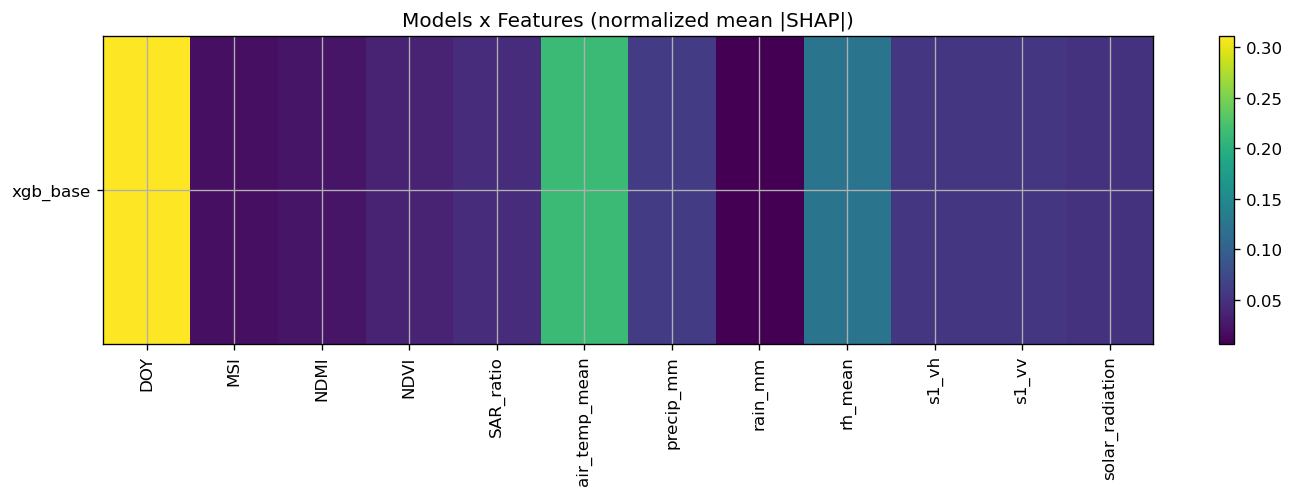

In [84]:
plot_heatmap(
    heatmap_wide,
    title="Models x Features (normalized mean |SHAP|)"
)

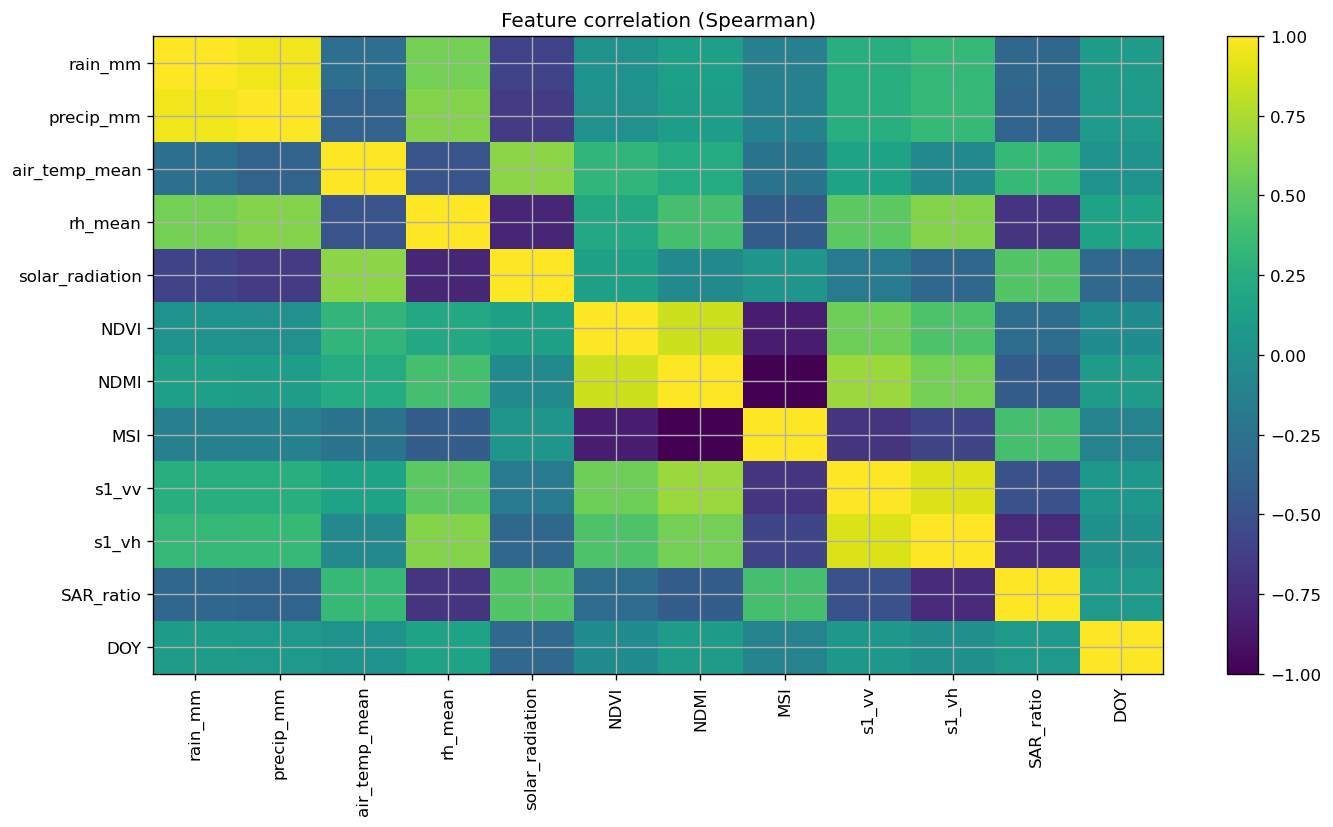

In [85]:
if corr is not None:
    plot_heatmap(
        corr,
        title="Feature correlation (Spearman)"
    )

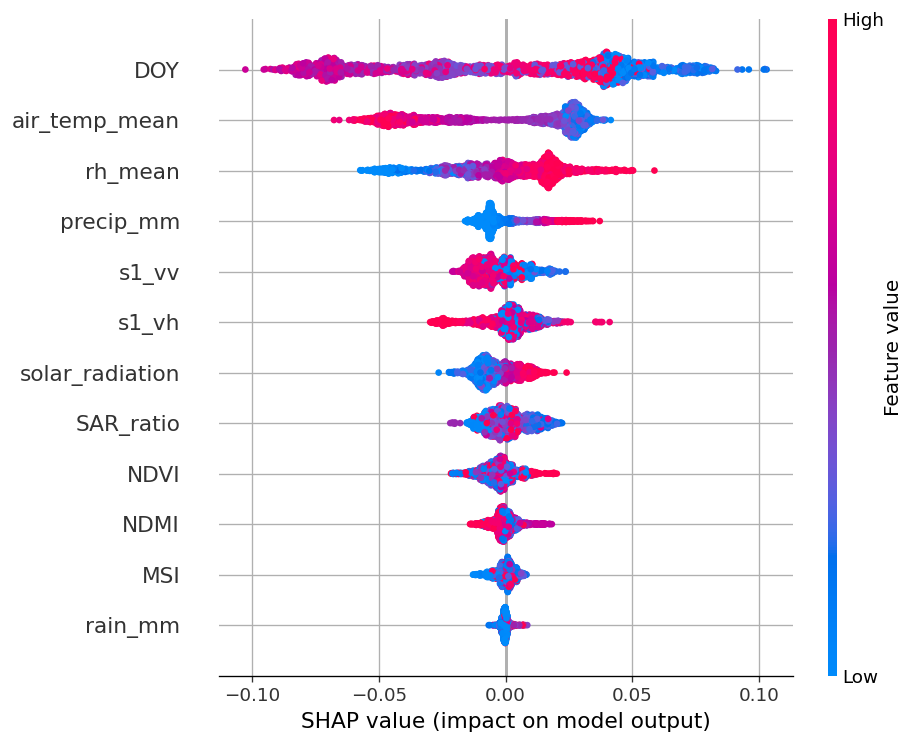

In [86]:
best_model = models["xgb_base"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
)

---

_Jakob Balkovec_